# Global Sea Level Rise
## Using NASA Satellite Data (1993-Present) for Analysis & Projection


Analysis of the NASA-SSH Global Mean Sea Level (GMSL) indicator dataset, derived from TOPEX/Poseidon, the Jason series, and Sentinel-6.

**Data source:** NASA Physical Oceanography PO.DAAC. DOI: 10.5067/NSIND-GMSV1

In [18]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates # Submodule for formatting date axes
from datetime import datetime, timedelta # Converting from decimal years to real datetime objects for panda/numpy ease
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson # Later testing for autocorrelation
import os

In [19]:
DATA_PATH = os.path.join(os.getcwd(), '..', 'data', 'NASA_SSH_GMSL_INDICATOR.txt')

# Load the file, skipping header lines
df = pd.read_csv(
    DATA_PATH,
    comment='H',
    sep=r'\s+', # r prefix fixes weird python backslash interpretation
    header=None,
    names=['decimal_year', 'gmsl_cm', 'gmsl_smoothed_cm']
)
MISSING_FLAG = 9.96921e+36 # Including as good practice
df.replace(MISSING_FLAG, np.nan, inplace=True) # Replace missing value flags with NaN
df.dropna(inplace=True) # Drop any such rows

print(f"Rows loaded: {len(df)}") # Making sure everything looks correct
print(f"Date range: {df['decimal_year'].min():.4f} to {df['decimal_year'].max():.4f}")
print(f"\nFirst 5 rows:")
df.head()

Rows loaded: 1723
Date range: 1993.0110 to 2026.2247

First 5 rows:


,decimal_year,gmsl_cm,gmsl_smoothed_cm
0,1993.010959,-0.230726,-0.445896
1,1993.030137,-0.303428,-0.466597
2,1993.049315,-0.460243,-0.472719
3,1993.068493,-0.599208,-0.454883
4,1993.087671,-0.635877,-0.425817


In [20]:
def decimal_year_to_date(decimal_year):
    year = int(decimal_year)
    remainder = decimal_year - year
    start_of_year = datetime(year, 1, 1)
    end_of_year = datetime(year + 1, 1, 1)
    days_in_year = (end_of_year - start_of_year).days
    return start_of_year + timedelta(days=remainder * days_in_year)

df['date'] = df['decimal_year'].apply(decimal_year_to_date)
df['date'] = pd.to_datetime(df['date']).dt.normalize()
df = df.set_index('date')
df.columns = ['Decimal Year', 'GMSL (cm)', 'GMSL Smoothed (cm)']

print(f"\nFirst 5 rows:")
df.head()


First 5 rows:


,Decimal Year,GMSL (cm),GMSL Smoothed (cm)
date,,,
1993-01-04,1993.010959,-0.230726,-0.445896
1993-01-12,1993.030137,-0.303428,-0.466597
1993-01-19,1993.049315,-0.460243,-0.472719
1993-01-26,1993.068493,-0.599208,-0.454883
1993-02-01,1993.087671,-0.635877,-0.425817


## A Note on 'Smoothing'
The raw `gmsl_cm` column contains direct weekly measurements, where every datapoint is computed independently. While the true signal, it contains short-term noise originating from a variety of factors, such as weather events, seasonal ocean expansions, etc. The `gmsl_smoothed_cm` column has been treated with a 60-day rolling average, applied by NASA in the original dataset. As such, each datapoint represents the average of the surrounding several weeks, making long-term trends much more visible.

For the purpose of this exploration, both columns will be utilised
1. **`GMSL (cm)`** for determining regression
2. **`GMSL Smoothed (cm)`** for visualisations

## Initial Dataset Info & Summary Statistics

In [21]:
print("Dataset Info:")
print(df.info())
print("\nSummary Statistics:")
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
DatetimeIndex: 1723 entries, 1993-01-04 to 2026-03-23
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Decimal Year        1723 non-null   float64
 1   GMSL (cm)           1723 non-null   float64
 2   GMSL Smoothed (cm)  1723 non-null   float64
dtypes: float64(3)
memory usage: 53.8 KB
None

Summary Statistics:


,Decimal Year,GMSL (cm),GMSL Smoothed (cm)
count,1723.000000,1723.000000,1723.000000
mean,2009.617382,4.765722,4.765514
std,9.606991,3.037979,3.031718
min,1993.010959,-0.693363,-0.562841
25%,2001.280822,2.269343,2.252103
50%,2009.627397,4.232709,4.233549
75%,2017.916438,7.457140,7.454087
max,2026.224657,10.974233,10.733371


### Preliminary Observations

Dataset is minuscule in filesize, being only 53.8 kb. All datapoints are of the correct datatype (*float64*), resultant of continuous measurements. No missing values are present in the dataset. 

Mean value shown to be **4.77 cm** (2 d.p.). Median value shown to be **4.23 cm** (2 d.p.).
1. Mean is slightly higher than the median, meaning the distribution is right-skewed.
2. This suggests the presence of more extreme recent values pulling the average up, which may be a signal of accelerating sea level rise.

Sea levels have risen from **-0.69 cm** (2 d.p.) to **10.97 cm** (2 d.p.) relative to 1993.

## Historical GMSL Time Series

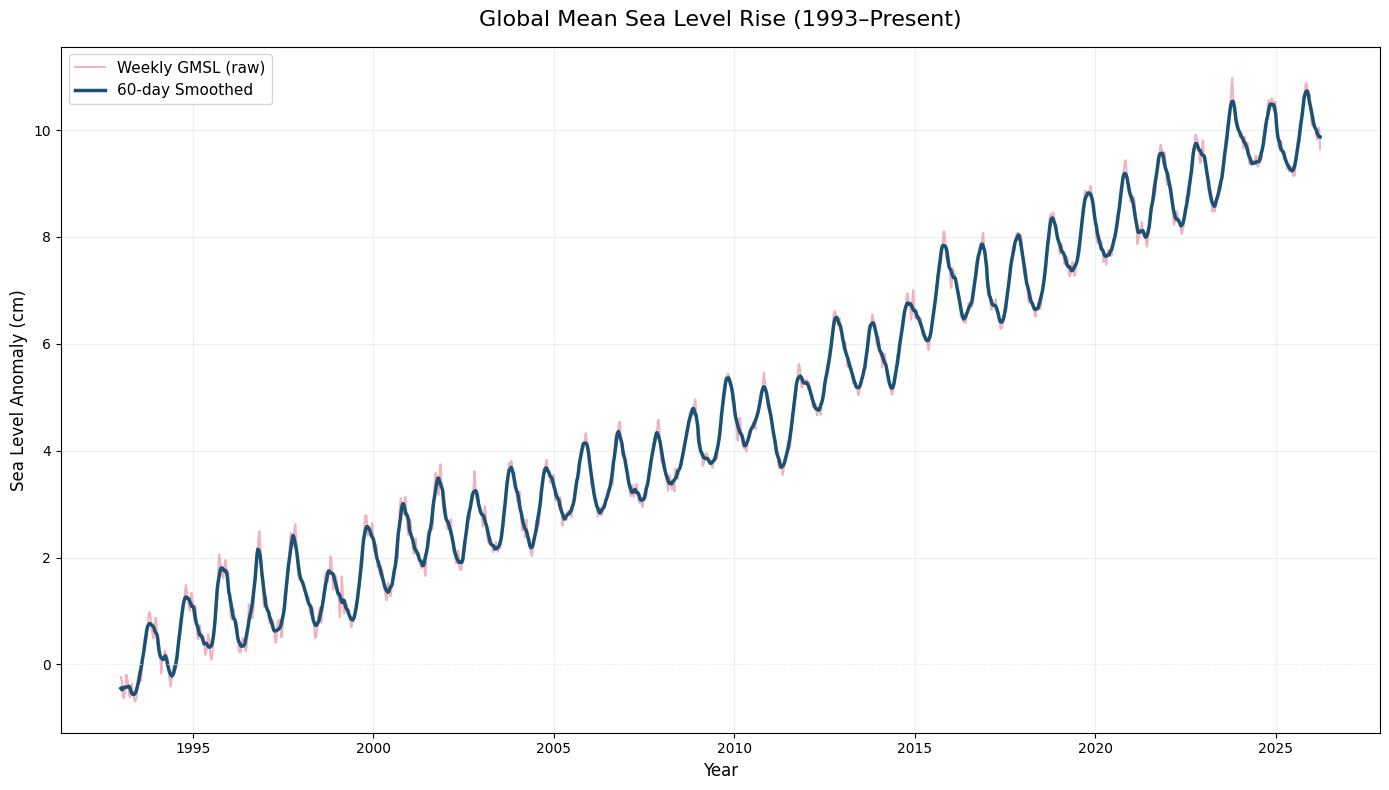

In [22]:
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(df.index, df['GMSL (cm)'], # Raw weekly measurements 
        color='#de425b', alpha=0.4, linewidth=1.5, 
        label='Weekly GMSL (raw)')

ax.plot(df.index, df['GMSL Smoothed (cm)'], # 60-day smoothed line
        color='#1a5276', alpha=1.0, linewidth=2.5,
        label='60-day Smoothed')

ax.set_title('Global Mean Sea Level Rise (1993–Present)', fontsize=16, pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Sea Level Anomaly (cm)', fontsize=12)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.axhline(y=0, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../images/gmsl_historical.png', dpi=150, bbox_inches='tight')
plt.show()

Visualisation of the data demonstrates a clear upwards-trending sawtooth pattern, repeating with yearly increments. The shape of the resultant graph can be explained by geophysical phenomena, such as the thermal expansion of the ocean with the change of seasons. 

Furthermore, a clear dip at the year 2011 can be observed. Upon further investigation, the downward shift has been linked to an exceptionally strong **La Niña** event. These weather occurrences temporarily lower global mean sea levels as winds associated drive moisture from the Pacific onto land, particularly over Australia, South America, and South Asia. Subsequent rainfall is temporarily stored in inland lakes and river systems, instead of returning to the ocean. This would explain the following rebound in the global mean in 2012-2013, as water drains back into the ocean.

## Amplitude Analysis

--- Smoothed Data ---
Amplitude trend: -0.0453 cm per decade
R²: 0.0242
p-value: 0.3801

--- Raw Data ---
Amplitude trend: -0.0888 cm per decade
R²: 0.0739
p-value: 0.1199


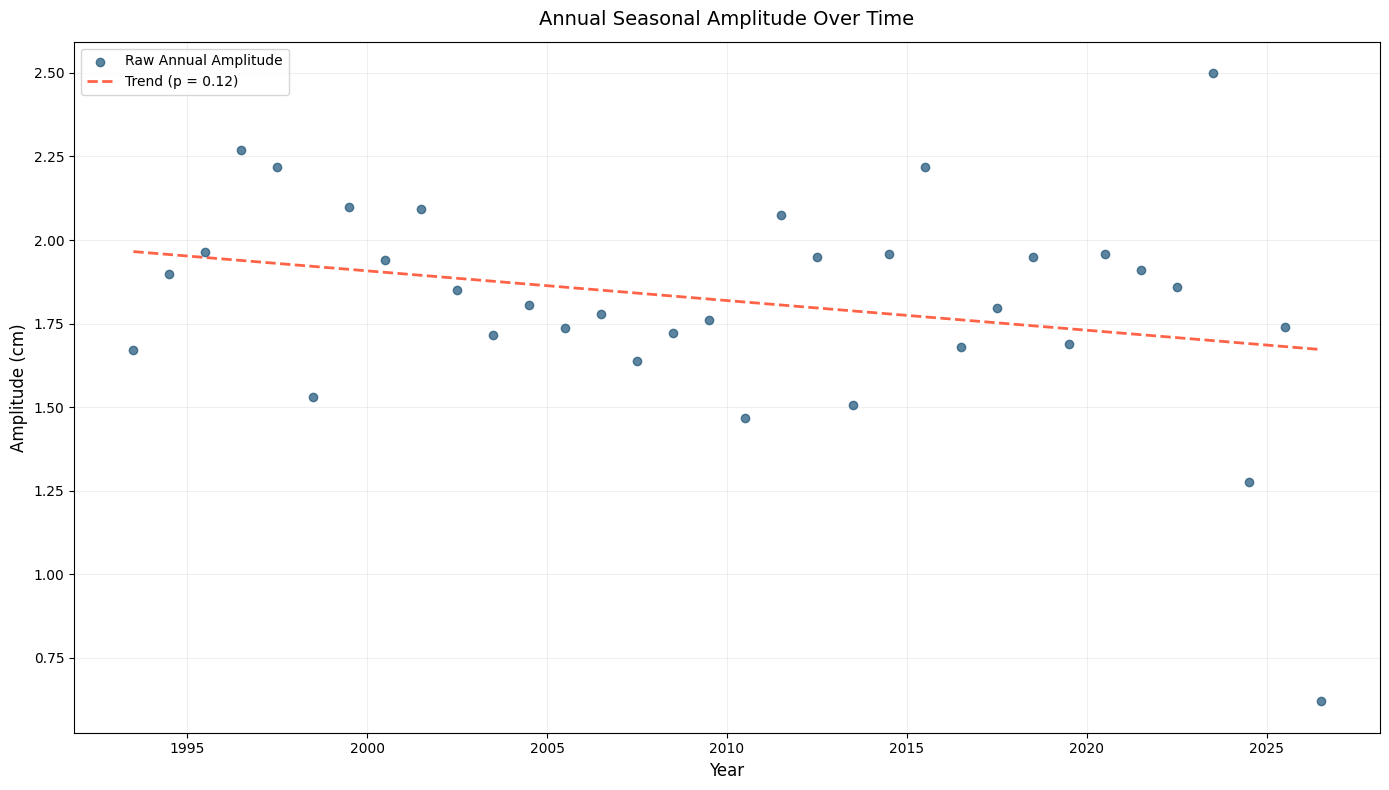

In [23]:
annual_max = df['GMSL (cm)'].resample('YE').max() # Calculate annual amplitude from raw GMSL
annual_min = df['GMSL (cm)'].resample('YE').min()
annual_amplitude = annual_max - annual_min

annual_max_s = df['GMSL Smoothed (cm)'].resample('YE').max() # Calculate annual amplitude from smoothed GMSL for comparison
annual_min_s = df['GMSL Smoothed (cm)'].resample('YE').min()
annual_amplitude_s = annual_max_s - annual_min_s

amp_years = np.array([t.year + 0.5 for t in annual_amplitude.index]) # Extract decimal years for regression 
amp_values = annual_amplitude.values
amp_values_s = annual_amplitude_s.values

slope, intercept, r_value, p_value, std_err = stats.linregress(amp_years, amp_values) # Linear regression on amplitude over time
slope_s, intercept_s, r_value_s, p_value_s, std_err_s = stats.linregress(amp_years, amp_values_s)

print("--- Smoothed Data ---")
print(f"Amplitude trend: {slope_s*10:.4f} cm per decade")
print(f"R²: {r_value_s**2:.4f}")
print(f"p-value: {p_value_s:.4f}")

print("\n--- Raw Data ---")
print(f"Amplitude trend: {slope*10:.4f} cm per decade")
print(f"R²: {r_value**2:.4f}")
print(f"p-value: {p_value:.4f}")

fig, ax = plt.subplots(figsize=(14, 8))

ax.scatter(amp_years, amp_values, color='#1a5276', alpha=0.7, # Scatter points of raw amplitude
           zorder=3, label='Raw Annual Amplitude')

reg_line = slope * amp_years + intercept
ax.plot(amp_years, reg_line, color='tomato', linewidth=2, # Regression line
        linestyle='--', label=f'Trend (p = {p_value:.2f})')

ax.set_title('Annual Seasonal Amplitude Over Time', fontsize=14, pad=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Amplitude (cm)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../images/amplitude_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Neither column shows a statistically significant trend in seasonal amplitude (**p > 0.05** in both cases). Visual inspection initially suggested the potential possibility of increase in seasonal amplitude, however quantitative analysis does not support such a conclusion.

Formal per-observation uncertainty estimates are not provided in the NASA-SSH Indicators User Guide (Willis et al., 2025). A conservative proxy of **±2.27 cm** is derivable 
from the Sentinel-6 orbit error reduction (OER) figure reported in the NASA-SSH V1 User Guide. This range is representative of corrected systematic error rather than residual uncertainty, and therefore an upper bound. Since this exceeds the full amplitude data range (**~1.25–2.50 cm**), error bars have been omitted. 

As such, the null result is now doubly supported: by the p-value, and by insufficient instrument precision to resolve small amplitude changes.


## Linear Trend Analysis & 2050 Projection

A linear regression is fitted to the full GMSL time series using the raw weekly measurements. The slope of this regression gives the long-term rate of sea level rise in cm per year, which is then extrapolated forward to 2050. Confidence intervals on the projection are derived from the standard error of the regression slope.

In [24]:
x = df['Decimal Year'].values # Prepare data for regression
y = df['GMSL (cm)'].values

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y) # Linear regression

print(f"Rate of rise:  {slope*10:.3f} cm per decade")
print(f"Rate of rise:  {slope*10:.3f} mm per year")
print(f"R²:            {r_value**2:.4f}")
print(f"p-value:       {p_value:.2e}")
print(f"Std error:     {std_err:.6f} cm/year")

Rate of rise:  3.099 cm per decade
Rate of rise:  3.099 mm per year
R²:            0.9604
p-value:       0.00e+00
Std error:     0.001517 cm/year


In [25]:
projection_year = 2050.5 # 2050 Projection
gmsl_2050 = slope * projection_year + intercept

n = len(x)
x_mean = np.mean(x) # # Var(y_new) = s² * (1 + 1/n + (x_new - x_mean)² / SS_xx)
se_projection = std_err * np.sqrt(1 + 1/n + (projection_year - x_mean)**2 / np.sum((x - x_mean)**2))
ci_95 = 1.96 * se_projection

print(f"Projected GMSL by mid-2050: {gmsl_2050:.2f} cm")
print(f"95% CI: ± {ci_95:.4f} cm")
print(f"Range: {gmsl_2050 - ci_95:.4f} to {gmsl_2050 + ci_95:.4f} cm")
print(f"\nTotal rise from 1993 baseline: {gmsl_2050:.2f} cm")

Projected GMSL by mid-2050: 17.44 cm
95% CI: ± 0.0030 cm
Range: 17.4321 to 17.4381 cm

Total rise from 1993 baseline: 17.44 cm


The projection of **17.44 cm** above the 1993 baseline by 2050 should be presented as a lower bound estimate under the assumption of a constant linear trend. The model so far does not account for a multitude of variables, such as growing evidence of acceleration in sea level rise, escalations of physical processes such as ice sheet dynamics, and growing climate uncertainty writ large. 

## Autocorrelation Analysis and Generalised Least Squares

OLS regression assumes independent and identically distributed errors. This assumption is unlikely for a weekly geophysical time series, where successive observations are expected to be strongly correlated.

In [26]:
y_pred_ols = slope * x + intercept # Compute OLS residuals
residuals = y - y_pred_ols

dw = durbin_watson(residuals) # Durbin-Watson statistic
print(f"Durbin-Watson statistic: {dw:.4f}")

Durbin-Watson statistic: 0.0413


A Durbin-Watson statistic of **0.0413** confirms strong positive autocorrelation in the residuals, meaning OLS standard errors are 
underestimated and the reported CI is unrealistically narrow. To correct for this, we fit a Generalised Least Squares (GLS) model with an autoregressive error structure, which produces more defensible standard errors and a more honest projection uncertainty.

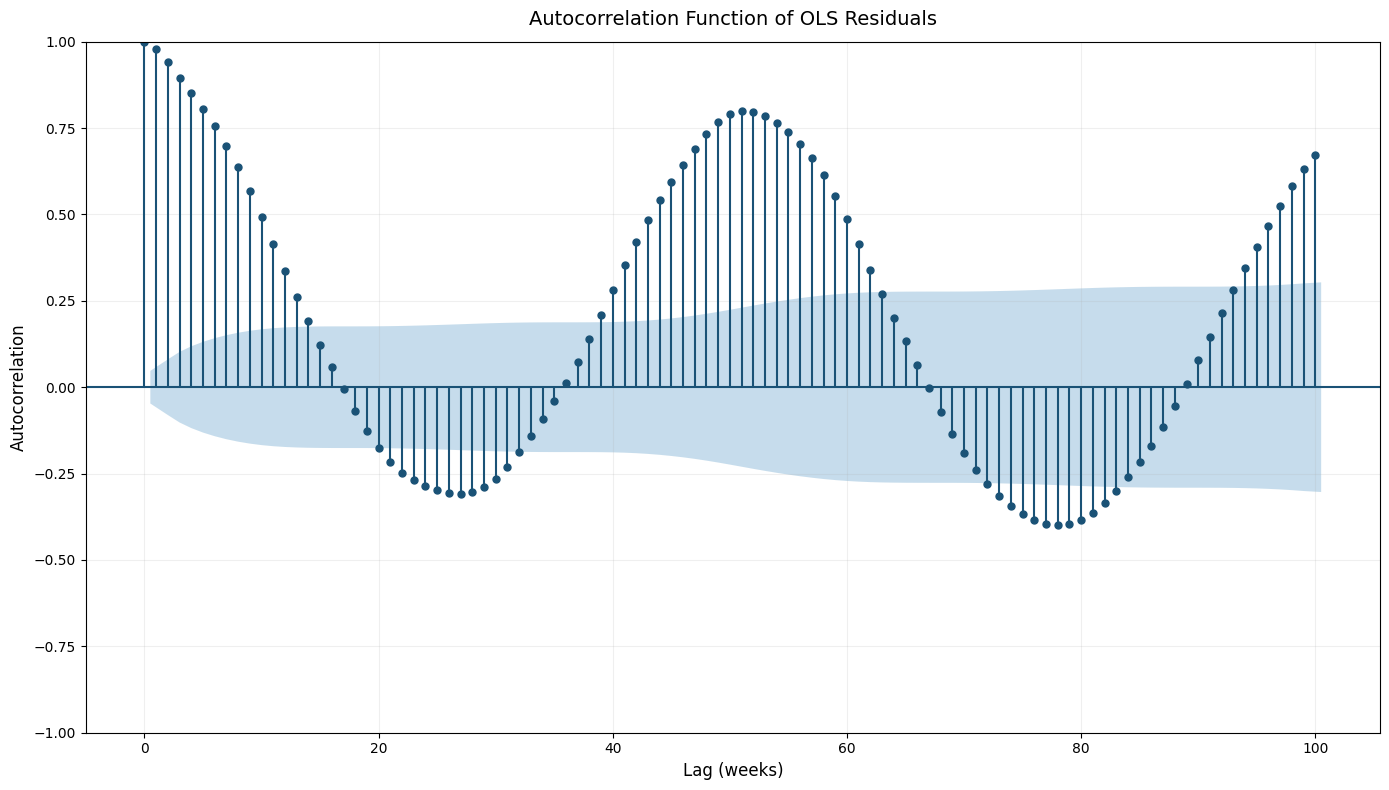

In [27]:
fig, ax = plt.subplots(figsize=(14, 8))

sm.graphics.tsa.plot_acf(residuals, lags=100, ax=ax,
                          color='#1a5276', vlines_kwargs={'colors': '#1a5276'})

ax.set_title('Autocorrelation Function of OLS Residuals', fontsize=14, pad=12)
ax.set_xlabel('Lag (weeks)', fontsize=12)
ax.set_ylabel('Autocorrelation', fontsize=12)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../images/acf_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

The ACF plot reveals two distinct autocorrelation structures in the OLS residuals:
1. Short-term persistence across the first ~15 lags
2. A sinusoidal oscillation with a period of approximately 52 weeks i.e. the annual seasonal cycle.

This confirms that a simple AR(1) correction is insufficient. A higher-order autoregressive structure is required to adequately model the error correlation.

In [28]:
from statsmodels.regression.linear_model import GLSAR

X_gls = sm.add_constant(x) # Fit GLSAR with AR(52) to account for seasonal autocorrelation in residuals
glsar_model = GLSAR(y, X_gls, rho=52)
glsar_result = glsar_model.iterative_fit(maxiter=10)

gls_slope = glsar_result.params[1] # Extract results
gls_intercept = glsar_result.params[0]
gls_se = glsar_result.bse[1]
gls_ci = glsar_result.conf_int(alpha=0.05)
n_gls = len(x)
x_mean_gls = np.mean(x)

print(f"GLSAR(52) Results:")
print(f"  Slope:         {gls_slope:.6f} cm/year")
print(f"  Rate of rise:  {gls_slope*10:.3f} mm/year")
print(f"  Std error:     {gls_se:.6f} cm/year")
print(f"  95% CI slope:  {gls_ci[1,0]:.6f} to {gls_ci[1,1]:.6f} cm/year")
print()
print(f"OLS comparison:")
print(f"  Slope:         {slope:.6f} cm/year")
print(f"  Std error:     {std_err:.6f} cm/year")
print(f"  SE inflation factor: {gls_se/std_err:.1f}x")

GLSAR(52) Results:
  Slope:         0.323639 cm/year
  Rate of rise:  3.236 mm/year
  Std error:     0.023600 cm/year
  95% CI slope:  0.277351 to 0.369928 cm/year

OLS comparison:
  Slope:         0.309897 cm/year
  Std error:     0.001517 cm/year
  SE inflation factor: 15.6x


GLSAR(52) fits 52 autoregressive coefficients iteratively, capturing both the short-term week-to-week persistence and the annual seasonal cycle identified in the ACF plot. Correcting for this autocorrelation structure produces a standard error **15.6x** larger than the OLS estimate. It is now evident that the OLS method previously utilised underestimated uncertainty by treating correlated observations as independent.

The corrected rate of rise is **3.236 mm/year** (vs 3.099 mm/year under OLS), with a 95% CI on the slope of 0.277 to 0.370 cm/year. 

## Residual Comparison: OLS vs GLSAR(52)

Plotting the residuals before and after the GLSAR(52) correction illustrates the practical effect of the autocorrelation adjustment. A well-corrected residual series should appear stationary, with no obvious structure or trend.

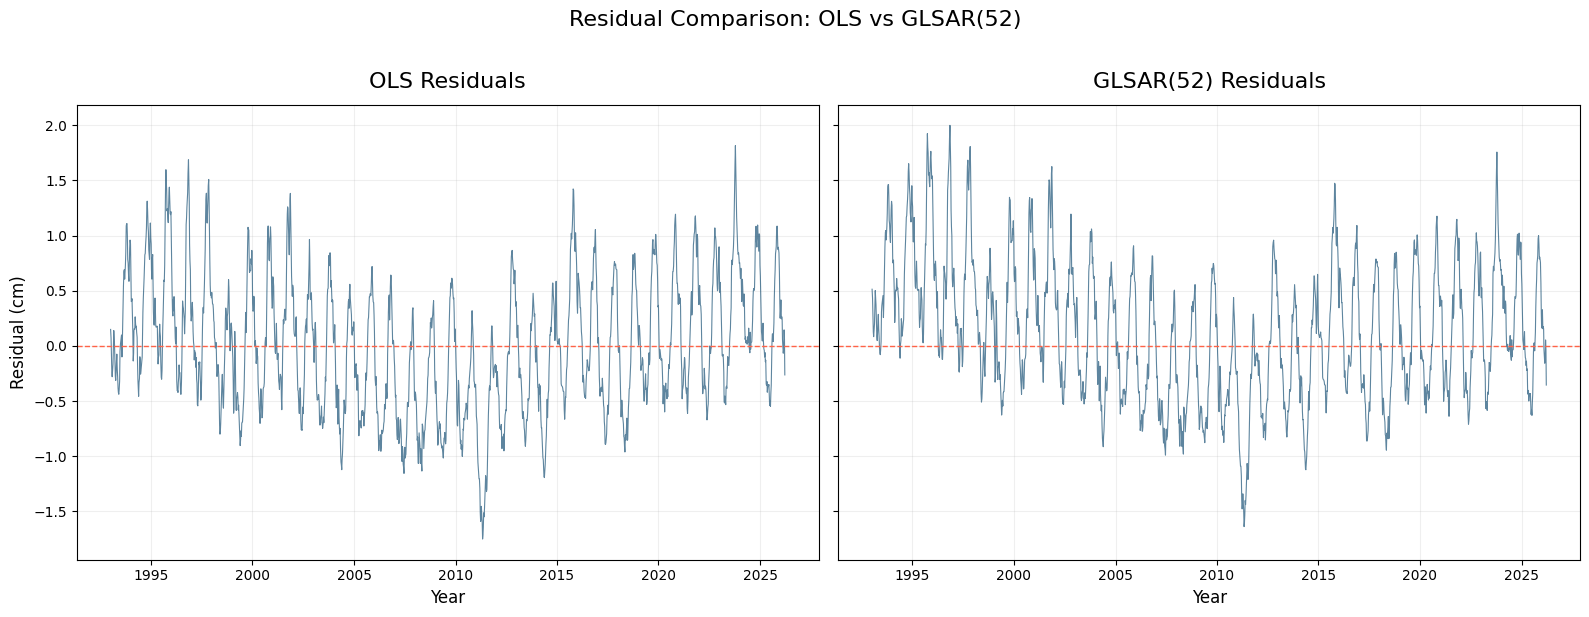

In [38]:
y_pred_gls = gls_slope * x + gls_intercept # GLSAR fitted values and residuals
residuals_gls = y - y_pred_gls

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

ax1.plot(df.index, residuals, color='#1a5276', linewidth=0.8, alpha=0.7) # OLS residuals
ax1.axhline(y=0, color='tomato', linestyle='--', linewidth=1)
ax1.set_title('OLS Residuals', fontsize=16, pad=12)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Residual (cm)', fontsize=12)
ax1.xaxis.set_major_locator(mdates.YearLocator(5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.grid(True, alpha=0.2)

ax2.plot(df.index, residuals_gls, color='#1a5276', linewidth=0.8, alpha=0.7) # GLSAR residuals
ax2.axhline(y=0, color='tomato', linestyle='--', linewidth=1)
ax2.set_title('GLSAR(52) Residuals', fontsize=16, pad=12)
ax2.set_xlabel('Year', fontsize=12)
ax2.xaxis.set_major_locator(mdates.YearLocator(5))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.grid(True, alpha=0.2)

plt.suptitle('Residual Comparison: OLS vs GLSAR(52)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/residual_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Both panels display a systematic bowl-shaped pattern in the residuals, confirming that the non-linearity in the GMSL record is a feature of the data rather than an artefact of the error structure. GLSAR(52) corrects for autocorrelation but cannot resolve curvature that a linear model is structurally unable to capture. This independently validates the quadratic model as the more appropriate fit. 

The persistent seasonal oscillation visible in both panels is expected, as GLSAR corrects the error structure rather than removing the underlying seasonal signal.

In [30]:
gmsl_2050_gls = gls_slope * projection_year + gls_intercept

n_gls = len(x)
x_mean_gls = np.mean(x)
se_proj_gls = gls_se * np.sqrt(1 + 1/n_gls + (projection_year - x_mean_gls)**2 /
                                np.sum((x - x_mean_gls)**2))
ci_95_gls = 1.96 * se_proj_gls

print(f"GLSAR(52) Projection to mid-2050: {gmsl_2050_gls:.2f} cm")
print(f"95% CI: ± {ci_95_gls:.2f} cm")
print(f"Range: {gmsl_2050_gls - ci_95_gls:.2f} to {gmsl_2050_gls + ci_95_gls:.2f} cm")

GLSAR(52) Projection to mid-2050: 17.86 cm
95% CI: ± 0.05 cm
Range: 17.81 to 17.91 cm


## Accommodating for Escalatory Factors

In [31]:
coeffs = np.polyfit(x, y, deg=2) # Fit quadratic (degree 2) polynomial
a, b, c = coeffs

print(f"Acceleration term: {a*2:.6f} cm/year²")

gmsl_2050_quad = a * projection_year**2 + b * projection_year + c # 2050 quadratic projection
print(f"Quadratic projection to mid-2050: {gmsl_2050_quad:.2f} cm")

Acceleration term: 0.005976 cm/year²
Quadratic projection to mid-2050: 22.15 cm


To maintain methodological consistency with the autocorrelation correction applied to the linear model, uncertainty on the quadratic projection is estimated using a block bootstrap with a block size of 52 weeks, matching the seasonal autocorrelation 
length identified in the ACF plot. This preserves the serial correlation structure of the time series during resampling, producing more honest confidence intervals.


In [52]:
np.random.seed(67)  # Reproducibility
n_bootstrap = 1000
block_size = 52
n = len(x)
n_blocks = int(np.ceil(n / block_size))
bootstrap_projections = []

for _ in range(n_bootstrap):
    block_starts = np.random.randint(0, n - block_size, size=n_blocks) # Draw random block start indices
    
    indices = np.concatenate([np.arange(start, start + block_size) # Concatenate blocks and trim to original length
                               for start in block_starts])[:n]
    
    x_boot = x[indices]
    y_boot = y[indices]
    
    coeffs_boot = np.polyfit(x_boot, y_boot, deg=2) # Fit quadratic to bootstrap sample
    proj = np.polyval(coeffs_boot, projection_year)
    bootstrap_projections.append(proj)

bootstrap_projections = np.array(bootstrap_projections)
ci_low_quad = np.percentile(bootstrap_projections, 2.5)
ci_high_quad = np.percentile(bootstrap_projections, 97.5)
ci_quad = (ci_high_quad - ci_low_quad) / 2

print(f"Quadratic block bootstrap projection to mid-2050: {gmsl_2050_quad:.2f} cm")
print(f"95% CI: {ci_low_quad:.2f} to {ci_high_quad:.2f} cm")
print(f"Approximate ± {ci_quad:.2f} cm")
print()
print(f"Updated summary of all projections:")
print(f"  OLS linear:       {gmsl_2050:.2f} cm (± 0.00 cm, unrealistic)")
print(f"  GLSAR(52) linear: {gmsl_2050_gls:.2f} cm (± {ci_95_gls:.2f} cm)")
print(f"  Quadratic:        {gmsl_2050_quad:.2f} cm ({ci_low_quad:.2f} to {ci_high_quad:.2f} cm)")

Quadratic block bootstrap projection to mid-2050: 22.15 cm
95% CI: 21.38 to 24.38 cm
Approximate ± 1.50 cm

Updated summary of all projections:
  OLS linear:       17.44 cm (± 0.00 cm, unrealistic)
  GLSAR(52) linear: 17.86 cm (± 0.05 cm)
  Quadratic:        22.15 cm (21.38 to 24.38 cm)


## Final Projection Plots

Three models are visualised: an OLS linear baseline, a GLSAR(52) corrected linear projection, and a quadratic model capturing observed acceleration. These are overlayed on top of the smoothed raw data from the original dataset. The shaded regions represent 95% confidence intervals. The "Present" marker serves as a separation between observed data and projected values.

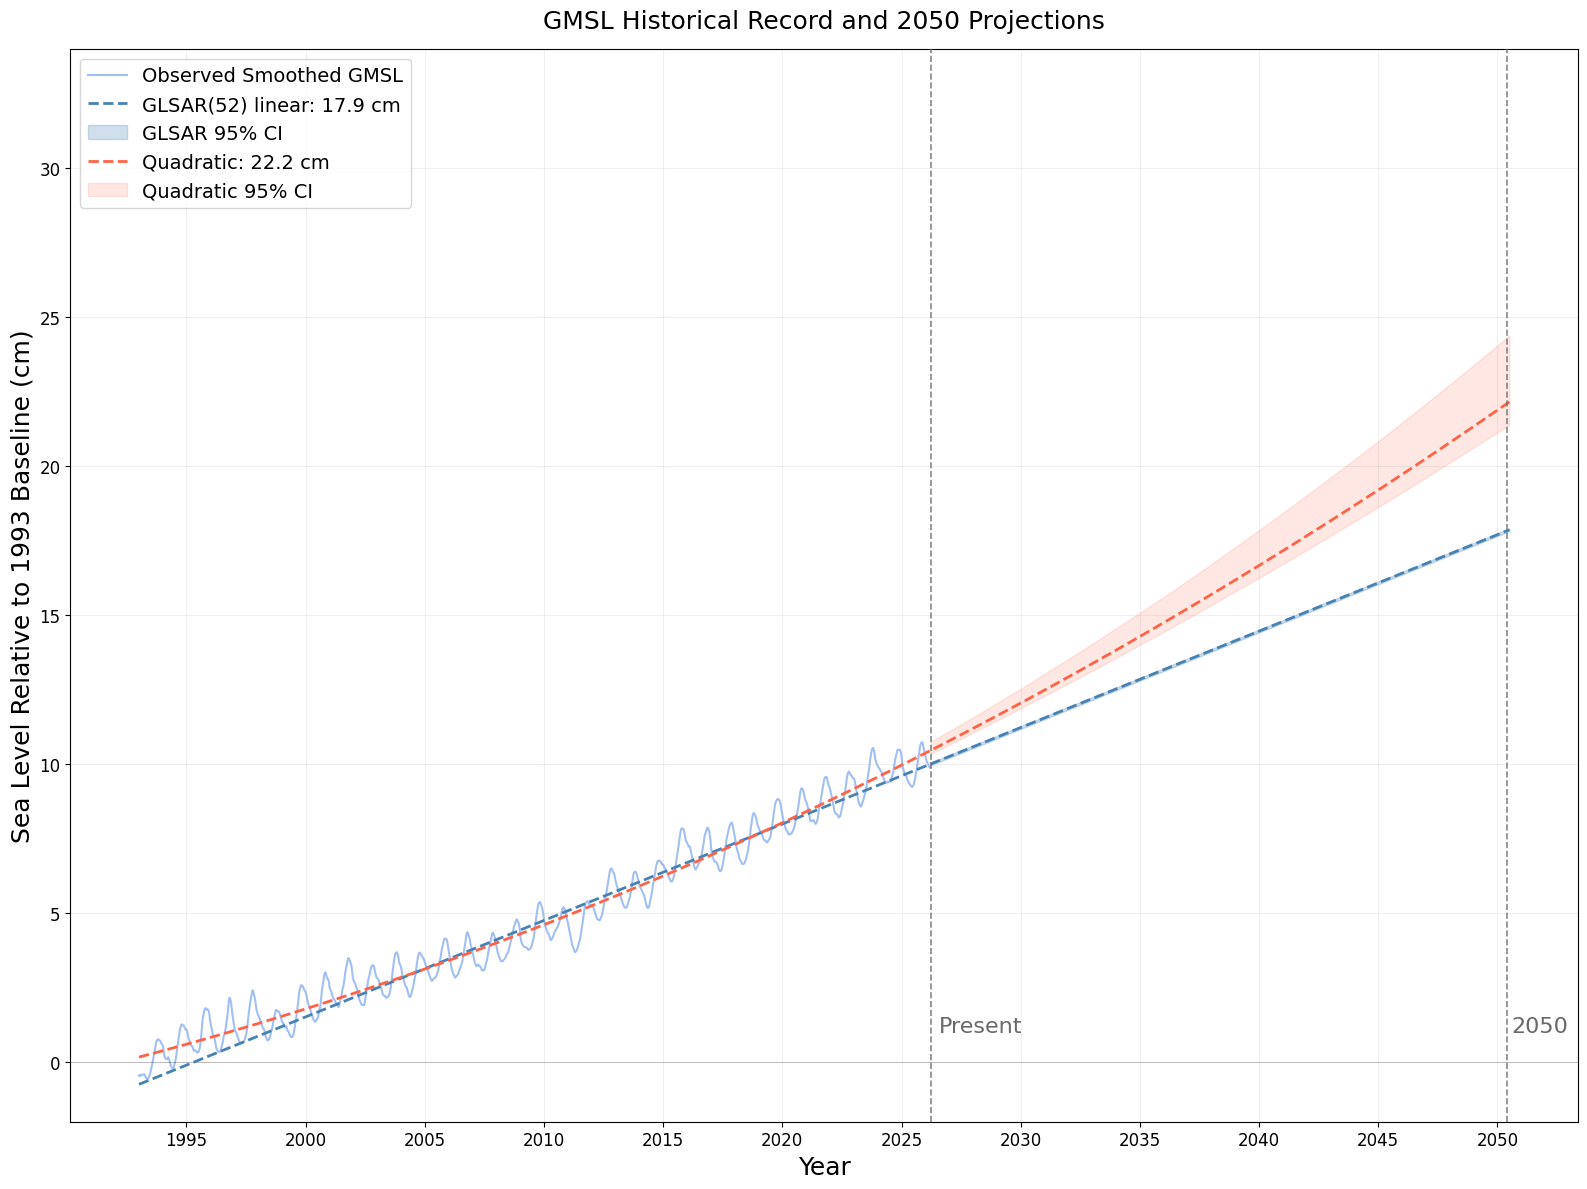

In [50]:
x_hist = np.linspace(x.min(), x.max(), 1000)
x_future = np.linspace(x.max(), projection_year, 200)
x_full = np.linspace(x.min(), projection_year, 1200)

def dec_to_date(dec_years):
    return [datetime(int(d), 1, 1) + timedelta(days=(d % 1) * 365)
            for d in dec_years]

hist_dates = dec_to_date(x_hist)
future_dates = dec_to_date(x_future)
full_dates = dec_to_date(x_full)

y_gls_hist = gls_slope * x_hist + gls_intercept
y_gls_future = gls_slope * x_future + gls_intercept
y_quad_full = np.polyval(coeffs, x_full)
y_quad_future = np.polyval(coeffs, x_future)

bootstrap_curves_future = []
np.random.seed(67)
for _ in range(1000):
    block_starts = np.random.randint(0, n - block_size, size=n_blocks)
    indices = np.concatenate([np.arange(s, s + block_size)
                               for s in block_starts])[:n]
    coeffs_boot = np.polyfit(x[indices], y[indices], deg=2)
    bootstrap_curves_future.append(np.polyval(coeffs_boot, x_future))

bootstrap_curves_future = np.array(bootstrap_curves_future)
ci_low_curve = np.percentile(bootstrap_curves_future, 2.5, axis=0)
ci_high_curve = np.percentile(bootstrap_curves_future, 97.5, axis=0)

se_future = gls_se * np.sqrt(1 + 1/n_gls + (x_future - x_mean_gls)**2 /
                              np.sum((x - x_mean_gls)**2))
ci_future = 1.96 * se_future

present_date = datetime(int(x.max()), 1, 1) + timedelta(days=(x.max() % 1) * 365)

fig, ax = plt.subplots(figsize=(16, 12))

ax.plot(df.index, df['GMSL Smoothed (cm)'],
        color='cornflowerblue', linewidth=1.5, alpha=0.6,
        label='Observed Smoothed GMSL', zorder=2)

ax.plot(hist_dates + future_dates,
        np.concatenate([y_gls_hist, y_gls_future]),
        color='steelblue', linewidth=2, linestyle='--',
        label=f'GLSAR(52) linear: {gmsl_2050_gls:.1f} cm', zorder=3)

ax.fill_between(future_dates,
                y_gls_future - ci_future,
                y_gls_future + ci_future,
                color='steelblue', alpha=0.25, label='GLSAR 95% CI')

ax.plot(full_dates, y_quad_full,
        color='tomato', linewidth=2, linestyle='--',
        label=f'Quadratic: {gmsl_2050_quad:.1f} cm', zorder=3)

ax.fill_between(future_dates, ci_low_curve, ci_high_curve,
                color='tomato', alpha=0.15,
                label=f'Quadratic 95% CI')

ax.axvline(x=present_date, color='dimgrey', linestyle='--',
           linewidth=1.2, alpha=0.8, zorder=4)
ax.text(datetime(2026, 8, 1), 1, 'Present', color='dimgrey', fontsize=16)

ax.axvline(x=datetime(2050, 6, 1), color='dimgrey',
           linestyle='--', linewidth=1.2, alpha=0.8, zorder=4)
ax.text(datetime(2050, 8, 1), 1, '2050', color='dimgrey', fontsize=16)

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)

ax.set_title('GMSL Historical Record and 2050 Projections',
             fontsize=18, pad=15)
ax.set_xlabel('Year', fontsize=18)
ax.set_ylabel('Sea Level Relative to 1993 Baseline (cm)', fontsize=18)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=14, loc='upper left')
ax.grid(True, alpha=0.2)
ax.set_ylim(-2, 34)

plt.tight_layout()
plt.savefig('../images/gmsl_projection.png', dpi=150, bbox_inches='tight')
plt.show()

The linear and quadratic models diverge meaningfully beyond our present, reflecting the acceleration term identified in the quadratic fit. By mid-2050, the GLSAR(52) linear model projects sea levels **17.9 cm** above the 1993 baseline, while the quadratic projects **22.2 cm** (95% CI: 21.3 to 24.3 cm). 

The linear projection should be treated as a conservative lower bound, as it assumes a constant rate of rise that the observational record does not support. The quadratic projection is the more physically plausible estimate, consistent with growing ice sheet contributions and thermal expansion over the period.

## Comparison against IPCC AR6 Benchmarks

The IPCC AR6 Working Group I report (Chapter 9, Table 9.SM.7) provides likely ranges for global mean sea level rise by 2050 under three emissions scenarios, relative to a 1995-2014 baseline. To overlay these against our projections, a baseline offset of **3.20 cm** is applied, representing the mean GMSL over 1995-2014 relative to our 1993 baseline. The three scenarios presented are indicate very low, intermediate, and very high emissions respectively.

In [34]:
baseline_mask = (df.index.year >= 1995) & (df.index.year <= 2014) # Calculate 1995-2014 mean from our dataset to convert IPCC baseline
baseline_offset = df.loc[baseline_mask, 'GMSL (cm)'].mean()

print(f"Mean GMSL 1995-2014 (relative to 1993 baseline): {baseline_offset:.2f} cm")
print(f"This offset must be added to IPCC figures to shift onto our 1993 baseline")

ipcc_scenarios = {
    'SSP1-1.9 (very low)': (15, 23),
    'SSP2-4.5 (intermediate)': (17, 26),
    'SSP5-8.5 (very high)': (20, 29)
}

print(f"\nIPCC AR6 ranges adjusted to 1993 baseline:")
ipcc_adjusted = {}
for scenario, (low, high) in ipcc_scenarios.items():
    adj_low = low + baseline_offset
    adj_high = high + baseline_offset
    ipcc_adjusted[scenario] = (adj_low, adj_high)
    print(f"  {scenario}: {adj_low:.1f} to {adj_high:.1f} cm")

Mean GMSL 1995-2014 (relative to 1993 baseline): 3.20 cm
This offset must be added to IPCC figures to shift onto our 1993 baseline

IPCC AR6 ranges adjusted to 1993 baseline:
  SSP1-1.9 (very low): 18.2 to 26.2 cm
  SSP2-4.5 (intermediate): 20.2 to 29.2 cm
  SSP5-8.5 (very high): 23.2 to 32.2 cm


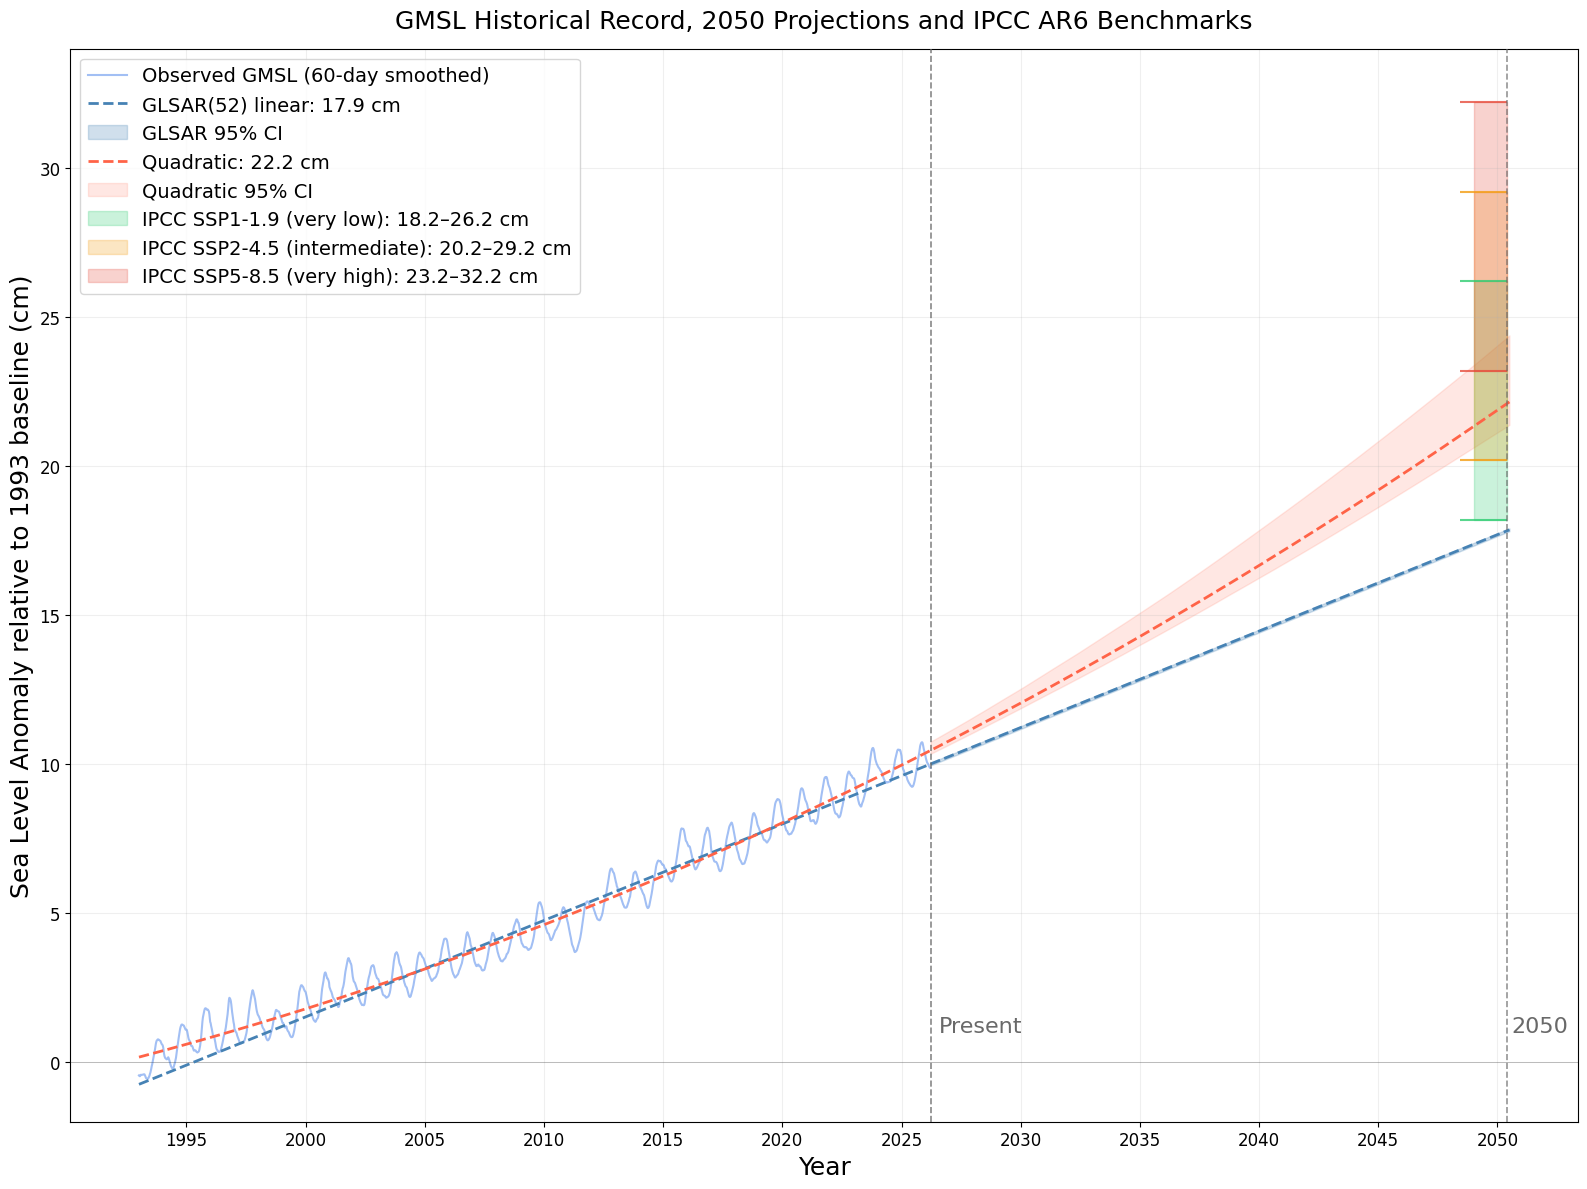

In [51]:
ipcc_colours = {
    'SSP1-1.9 (very low)': '#2ecc71',
    'SSP2-4.5 (intermediate)': '#f39c12',
    'SSP5-8.5 (very high)': '#e74c3c'
}

x_hist = np.linspace(x.min(), x.max(), 1000)
x_future = np.linspace(x.max(), projection_year, 200)
x_full = np.linspace(x.min(), projection_year, 1200)

def dec_to_date(dec_years):
    return [datetime(int(d), 1, 1) + timedelta(days=(d % 1) * 365)
            for d in dec_years]

hist_dates = dec_to_date(x_hist)
future_dates = dec_to_date(x_future)
full_dates = dec_to_date(x_full)

y_gls_hist = gls_slope * x_hist + gls_intercept
y_gls_future = gls_slope * x_future + gls_intercept
y_quad_full = np.polyval(coeffs, x_full)

bootstrap_curves_future = []
np.random.seed(67)
for _ in range(1000):
    block_starts = np.random.randint(0, n - block_size, size=n_blocks)
    indices = np.concatenate([np.arange(s, s + block_size)
                               for s in block_starts])[:n]
    coeffs_boot = np.polyfit(x[indices], y[indices], deg=2)
    bootstrap_curves_future.append(np.polyval(coeffs_boot, x_future))

bootstrap_curves_future = np.array(bootstrap_curves_future)
ci_low_curve = np.percentile(bootstrap_curves_future, 2.5, axis=0)
ci_high_curve = np.percentile(bootstrap_curves_future, 97.5, axis=0)

se_future = gls_se * np.sqrt(1 + 1/n_gls + (x_future - x_mean_gls)**2 /
                              np.sum((x - x_mean_gls)**2))
ci_future = 1.96 * se_future

present_date = datetime(int(x.max()), 1, 1) + timedelta(days=(x.max() % 1) * 365)

fig, ax = plt.subplots(figsize=(16, 12))

ax.plot(df.index, df['GMSL Smoothed (cm)'],
        color='cornflowerblue', linewidth=1.5, alpha=0.6,
        label='Observed GMSL (60-day smoothed)', zorder=2)

ax.plot(hist_dates + future_dates,
        np.concatenate([y_gls_hist, y_gls_future]),
        color='steelblue', linewidth=2, linestyle='--',
        label=f'GLSAR(52) linear: {gmsl_2050_gls:.1f} cm', zorder=3)

ax.fill_between(future_dates,
                y_gls_future - ci_future,
                y_gls_future + ci_future,
                color='steelblue', alpha=0.25, label='GLSAR 95% CI')

ax.plot(full_dates, y_quad_full,
        color='tomato', linewidth=2, linestyle='--',
        label=f'Quadratic: {gmsl_2050_quad:.1f} cm', zorder=3)

ax.fill_between(future_dates, ci_low_curve, ci_high_curve,
                color='tomato', alpha=0.15,
                label=f'Quadratic 95% CI')

# IPCC AR6 ranges at 2050
ipcc_x = [datetime(2049, 1, 1), datetime(2050, 6, 1)]
for scenario, (adj_low, adj_high) in ipcc_adjusted.items():
    colour = ipcc_colours[scenario]
    ax.fill_between(ipcc_x, [adj_low, adj_low], [adj_high, adj_high],
                    color=colour, alpha=0.25,
                    label=f'IPCC {scenario}: {adj_low:.1f}–{adj_high:.1f} cm')
    ax.hlines(y=[adj_low, adj_high], xmin=datetime(2048, 6, 1),
              xmax=datetime(2050, 6, 1), colors=colour,
              linewidth=1.5, alpha=0.8)

ax.axvline(x=present_date, color='dimgrey', linestyle='--',
           linewidth=1.2, alpha=0.8, zorder=4)
ax.text(datetime(2026, 8, 1), 1, 'Present', color='dimgrey', fontsize=16)
ax.axvline(x=datetime(2050, 6, 1), color='dimgrey',
           linestyle='--', linewidth=1.2, alpha=0.7, zorder=4)
ax.text(datetime(2050, 8, 1), 1, '2050', color='dimgrey', fontsize=16)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)

ax.set_title('GMSL Historical Record, 2050 Projections and IPCC AR6 Benchmarks',
             fontsize=18, pad=15)
ax.set_xlabel('Year', fontsize=18)
ax.set_ylabel('Sea Level Anomaly relative to 1993 baseline (cm)', fontsize=18)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=14, loc='upper left')
ax.grid(True, alpha=0.2)
ax.set_ylim(-2, 34)

plt.tight_layout()
plt.savefig('../images/gmsl_ipcc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Our GLSAR(52) linear projection of **17.9 cm** falls below the lower bound of all three IPCC scenarios, consistent with a constant linear trend that does not capture acceleration. 

The quadratic projection of **22.2 cm** sits within the SSP1-1.9 likely range (18.2 to 26.2 cm) and approaches the lower bound of SSP2-4.5 (20.2 to 29.2 cm), suggesting it is most consistent with a low-to-intermediate emissions trajectory. This highlights the significance of the acceleration term identified in the quadratic fit, and contextualises our projection within the scientific consensus.

In [ ]:
projection_year_2100 = 2100.5

gmsl_2100_quad = a * projection_year_2100**2 + b * projection_year_2100 + c # Quadratic projection to 2100

np.random.seed(67) # Block bootstrap CI for 2100
bootstrap_2100 = []

for _ in range(1000):
    block_starts = np.random.randint(0, n - block_size, size=n_blocks)
    indices = np.concatenate([np.arange(s, s + block_size)
                               for s in block_starts])[:n]
    coeffs_boot = np.polyfit(x[indices], y[indices], deg=2)
    proj = np.polyval(coeffs_boot, projection_year_2100)
    bootstrap_2100.append(proj)

bootstrap_2100 = np.array(bootstrap_2100)
ci_low_2100 = np.percentile(bootstrap_2100, 2.5)
ci_high_2100 = np.percentile(bootstrap_2100, 97.5)

ipcc_2100_scenarios = {
    'SSP1-1.9 (very low)': (28, 55),
    'SSP2-4.5 (intermediate)': (37, 71),
    'SSP5-8.5 (very high)': (63, 101)
}

# IPCC AR6 likely ranges for 2100
# Source: IPCC AR6 WG1 Chapter 9, Table 9.SM.7; AR6 Synthesis Report Figure 3.4

print("IPCC AR6 2100 ranges adjusted to 1993 baseline:")
ipcc_2100_adjusted = {}
for scenario, (low, high) in ipcc_2100_scenarios.items():
    adj_low = low + baseline_offset
    adj_high = high + baseline_offset
    ipcc_2100_adjusted[scenario] = (adj_low, adj_high)
    print(f"  {scenario}: {adj_low:.1f} to {adj_high:.1f} cm")

print(f"\nOur quadratic projection: {gmsl_2100_quad:.2f} cm")
print(f"95% CI: {ci_low_2100:.2f} to {ci_high_2100:.2f} cm")

print(f"Rise from 2050 to 2100: {gmsl_2100_quad - gmsl_2050_quad:.2f} cm")

IPCC AR6 2100 ranges adjusted to 1993 baseline:
  SSP1-1.9 (very low): 31.2 to 58.2 cm
  SSP2-4.5 (intermediate): 40.2 to 74.2 cm
  SSP5-8.5 (very high): 66.2 to 104.2 cm

Our quadratic projection: 57.33 cm
95% CI: 53.05 to 68.78 cm
Rise from 2050 to 2100: 35.18 cm


## Rising Higher: Projections by 2100

The quadratic model projects a rise of **22.2 cm** (95% CI: 21.3 to 24.3 cm) by 2050 and **57.3 cm** (95% CI: 52.5 to 68.8 cm) by 2100, both relative to the 1993 baseline. The additional rise of **35.2 cm** between 2050 and 2100 is nearly three times the projected rise between present and 2050, directly reflecting the compounding effect of the acceleration term.

At 2100, our projection sits at the upper bound of the IPCC AR6 SSP1-1.9 likely range (31.2 to 58.2 cm) and below the lower bound of SSP2-4.5 (40.2 to 74.2 cm), suggesting consistency with a low-to-intermediate emissions trajectory. Importantly, this projection is derived purely from observed historical acceleration and carries no assumptions about future emissions.

